# Categorizing Movies
TEAM 7: Arik Lee, Jonah Millard, Emilia Silverman, Magalie Huertero

### Description
Our goal for this project is to be able to categorize scripts by movie genres — Action, Comedy, Thriller, Romance, Horror, Drama, Fantasy, Musical, Sci-fi. Mystery, Crime, War, and Family using natural language processing techniques. We will use Term frequency - Inverse Document Frequency to normalize the frequency of words throughout various movie scripts. To understand the emotional tone of the scripts we will use sentiment analysis, the scripts and comments for these scripts will first be converted to numerical representations using Bag-of-Words before running through our model. In addition we will be using Frequency Analysis to examine which words appear the most in scripts per genre. Finally with Similarity Analysis we will be computing cosine similarly and using KNN to determine which method has a higher accuracy score when determining genre. Since certain genres like horror or musicals tend to use more descriptive words we expect their genres to have higher accuracy scores regardless of method.

In [67]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

## Dataset
We constructed our dataset through webscraping we were able to collect 1297 movies from the **Internet Movie Script Database**. Since this website provides movie scripts along with user discussions and comments we decided to also scrape the comments left by reviewers. These comments often contain reactions, opinions, and descriptions about the tone of the movie. Since our project places an emphasis on sentiment analysis for genre classification, these comments provide valuable contextual information that may reflect how audiences perceive the emotional tone of a script. For example, comments might mention whether a script is “funny,” “suspenseful,” “scary,” or “romantic,” which can provide additional details for classification.

Our Observations contain: 

*Movie Title – the name of the movie associated with the script*

*Script Text – the full movie script extracted from the IMSDb page*

*Reviewer Comments – user comments discussing the script*


In [68]:
base_url = "https://imsdb.com/"
start_url = "https://imsdb.com/all-scripts.html"

# gets the page with all script links
response = requests.get(start_url)
soup = BeautifulSoup(response.text, "html.parser")

# find links to movie pages
movie_links = []

for a in soup.select("p a"):
    href = a.get("href")
    if href and href.startswith("/Movie Scripts/"):
        movie_links.append(urljoin(base_url, href))

print("Movie pages found:", len(movie_links))
print(movie_links[:10])

Movie pages found: 1297
['https://imsdb.com/Movie Scripts/10 Things I Hate About You Script.html', 'https://imsdb.com/Movie Scripts/12 Script.html', 'https://imsdb.com/Movie Scripts/12 and Holding Script.html', 'https://imsdb.com/Movie Scripts/12 Monkeys Script.html', 'https://imsdb.com/Movie Scripts/12 Years a Slave Script.html', 'https://imsdb.com/Movie Scripts/127 Hours Script.html', 'https://imsdb.com/Movie Scripts/1492: Conquest of Paradise Script.html', 'https://imsdb.com/Movie Scripts/15 Minutes Script.html', 'https://imsdb.com/Movie Scripts/17 Again Script.html', 'https://imsdb.com/Movie Scripts/187 Script.html']


In [69]:
def extract_comments(movie_soup): # comments
    comments = []

    text_lines = movie_soup.get_text("\n", strip=True).split("\n")

    capture = False
    current_comment = []
    for line in text_lines:
        if "User Comments for" in line: #start
            capture = True
            continue
        if "Add your own comment" in line: #end
            break
        if capture:
            if line == "* * *": # divider of comments
                if current_comment:
                    comments.append(" ".join(current_comment))
                    current_comment = []
            else:
                current_comment.append(line)

    if current_comment:
        comments.append(" ".join(current_comment))

    return comments

*Created Manual Genre Vectors to use as a baseline for cosine similarity*

In [70]:
MANUAL_GENRE_VECTORS = {
    "Horror": [
        "blood", "scream", "killer", "dark", "death", "fear", "ghost", "knife", "night", "evil",
        "dead", "body", "monster", "shadow", "haunted", "attack", "hide", "danger", "panic", "cry",
        "terrified", "grave", "curse", "demon", "victim", "murder", "skull", "forest", "shock", "creature"
    ],
    "Crime": [
        "police", "money", "gun", "car", "bank", "street", "boss", "deal", "stole", "detective",
        "robbery", "murder", "case", "criminal", "evidence", "cop", "mafia", "hit", "jail", "drug",
        "suspect", "thief", "lawyer", "court", "gang", "escape", "witness", "track", "investigate", "bullet"
    ],
    "War": [
        "army", "battle", "soldier", "enemy", "captain", "general", "attack", "bomb", "fight", "weapon",
        "mission", "troop", "tank", "warfare", "gunfire", "uniform", "commander", "base", "front", "march",
        "victory", "defeat", "radio", "orders", "camp", "battlefield", "explosion", "rifle", "navy", "aircraft"
    ],
    "Drama": ["emotion", "emotional", "crying", "fight", "fighting", "betrayal", "argument", "regret", "love",
        "cheat", "cheating", "pain", "loss", "grief", "nostalgia", "frustrated", "confused", "miscalculations", 
        "misunderstanding", "significant", "partner", "decision", "choice", "regret", "memory", "memories", "sad",
        "life", "change", "changes", "trust", "lies", "lying", "conflict", "bond", "bonded"
    ],
    "Thriller": ["murder", "crime", "secret", "suspense", "dangerous", "killer", "victim", "traitor", "spy", "spies",
        "agent", "weapon", "weapons", "gun", "guns", "investigation", "hidden", "suspense", "tense", "trap", 
        "escape", "night", "dark", "revenge", "observe", "observed", "evidence", "clue", "betrayal", "panic",
        "discover", "hide", "hiding", "sudden", "suddenly"
    ],
    "Fantasy": ["magic", "wizard", "witch", "spell", "alchemy", "amulet", "armies", "armor", "arrow", "axe", "barbarian",
        "battle", "beast", "bewitch","bones", "brave", "castle", "cauldron", "cave", "centaur", "chamber", "chariot",
        "charm", "conjure", "crown", "curse", "devil", "dragon","dream", "druid", "dungeon", "dwarves", "eerie", "elf", 
        "enchanted", "enchantress", "faerie", "fairy", "fang", "fantastical", "ghoul", "giant", "glitter", "goblin", "hermit", 
        "heroic", "horns"
    ],
    "Musical": ["accompaniment", "actor", "actress", "aria", "arrangement", "audience", "audition", "backstage", "ballad", "band", 
        "beat", "belt", "cabaret","camera", "cast", "celebration", "character", "chorus", "choreographer", "climax", "composer",
        "composition", "conductor", "conductor", "costume", "cresendo", "cue", "curtain", "dance", "dancer", "debut", "director", "diva",
        "duet", "encore", "ensemble", "entertainment", "expression", "finale", "formation", "gesture", "glamor", "groove", 
        "harmony", "improv", "instrument", "interlude", "jazz", "kickline", "lead", "lights", "lyrics", "melody", "microphone", "montage", "musical", 
        "orchestra", "performance", "rhythem", "sing", "singer", "song", "spotlight", "stage", "story", "swing", "tap", "tempo", "tenor", 
        "theater", "tone", "twirl", "vibrato", "voice"
    ],
    "Sci-Fi": ["android", "anomaly", "antimatter", "artifact", "artificial", "astronaut", "atmosphere", "avatar", "biomechanical", 
        "biotechnology", "blackhole", "civilization", "clone", "colony", "computer", "conciousness", "cosmic", "cryochamber", "cyberspace", "data", 
        "dimension", "discovery", "drone", "empire", "energy", "evolution", "experiment", "exploration", "extraterrestrial", "forcefield", "future", 
        "galaxy", "generator", "genetic", "gravity", "hologram","hyperspace", "interdimensional", "invasion", "laboratory", "laser", "lifeform", "machine", 
        "meteor", "microchip", "mutation", "neural", "organism", "particle", "photon", "planet", "portal", "quantum", "radiation", "research", "robot", "satellite", 
        "scientist", "spaceship", "supernova", "teleportation", "timewarp", "wormhole"
    ],
    "Action": ["go", "run", "move", "hurry", "stop", "wait", "look", "get", "take", "come", "help", "shoot", "kill", "fight", "attack", "cover", "down", "now", 
        "fast", "quick", "gun", "bomb", "target", "enemy", "mission", "escape", "chase", "danger", "secure", "clear"
    ],
    "Comedy": ["funny", "joke", "laugh", "crazy", "weird", "silly", "oops", "awkward", "sorry", "what", "why", "really", "classic", "wait", "look", 
        "dude", "bro", "man", "cousin", "guy", "exactly", "literally", "party", "drink", "dance","chill", "stupid", "idiot", "seriously", "relax"
    ],
    "Family": ["secret", "believe", "magic", "legend", "discover", "hidden", "forever", "imagine", "journey", "wonder", "together", "promise", "brave", "listen", "heart", 
        "home", "belong", "trust", "change", "remember", "hurry", "escape", "trouble", "monster", "finally", "impossible", "danger", "team", "mission", "destiny"
    ],
    "Romance": ["love", "heart", "kiss", "romance", "romantic", "passion", "darling", "sweet", "desire", "affection", "embrace", "devotion", "soulmate", "beloved", "tender", "date",
        "candlelight", "roses", "charm", "attraction", "intimacy", "admire", "adorable", "flirt", "longing", "connection", "forever", "together", "dream", "hug", "cherish"
    ],
    "Mystery": ["murder", "detective", "clue", "suspect", "alibi", "investigation", "evidence", "crime", "secret", "witness", "disappearance", "case", "killer", "police", 
        "scene", "shadow", "truth", "lie", "victim", "fingerprint", "interrogation", "motive", "puzzle", "hidden", "message", "locked", "reveal", "trail", "danger", "solve"
    ]
    
}

STOP_WORDS = {
    "a", "an", "and", "are", "as", "at", "be", "but", "by", "for", "from", "had", "has", "have",
    "he", "her", "hers", "him", "his", "i", "if", "in", "into", "is", "it", "its", "me", "my",
    "of", "on", "or", "our", "she", "that", "the", "their", "them", "they", "this", "to", "was",
    "we", "were", "with", "you", "your"
}


In [71]:
CORPUS = set()
data = []

genre_links = [
    "https://imsdb.com/genre/Action",
    "https://imsdb.com/genre/Comedy",
    "https://imsdb.com/genre/Romance",
    "https://imsdb.com/genre/Thriller",
    "https://imsdb.com/genre/Horror",
    "https://imsdb.com/genre/Drama",
    "https://imsdb.com/genre/Fantasy",
    "https://imsdb.com/genre/Musical",
    "https://imsdb.com/genre/Sci-Fi",
    "https://imsdb.com/genre/Mystery",
    "https://imsdb.com/genre/Crime",
    "https://imsdb.com/genre/War",
    "https://imsdb.com/genre/Family"
]

valid_genres = {
    "Action", "Comedy", "Romance", "Thriller", "Horror",
    "Drama", "Fantasy", "Musical", "Sci-Fi", "Mystery",
    "Crime", "War", "Family"
}

for genre_link in genre_links:
    response = requests.get(genre_link)
    soup = BeautifulSoup(response.text, "html.parser")

    movie_links = [a["href"] for a in soup.select("p a")]

    for movie_link in movie_links[:100]:
        movie_url = urljoin(genre_link, movie_link)
        movie_response = requests.get(movie_url)
        movie_soup = BeautifulSoup(movie_response.text, "html.parser")

        title = movie_soup.title.get_text(strip=True).split(" Script")[0]

        genres = [genre_link.split("/")[-1]]

        for a in movie_soup.find_all("a"):
            title_attr = a.get("title")

            if title_attr:
                first_word = title_attr.split()[0]
                if first_word in valid_genres:
                    genres.append(first_word)

        genres = list(set(genres))

        comments = extract_comments(movie_soup)

        script_link = None
        for a in movie_soup.select("a"):
            if "read" in a.get_text(strip=True).lower():
                href = a.get("href")
                if href:
                    script_link = urljoin(movie_url, href)
                    break

        if not script_link:
            continue

        script_response = requests.get(script_link)
        script_soup = BeautifulSoup(script_response.text, "html.parser")
        script_container = script_soup.find("td", class_="scrtext")

        if script_container:
            script_text = script_container.get_text("\n", strip=True)
            CORPUS.update(script_text.split())

            data.append({
                "title": title,
                "genre": genres,
                "script": script_text,
                "comments": comments
            })

df = pd.DataFrame(data)
print(df.head())
print(df["genre"].value_counts())


                 title                              genre  \
0           15 Minutes          [Action, Thriller, Crime]   
1                 2012  [Drama, Action, Thriller, Sci-Fi]   
2   30 Minutes or Less                   [Comedy, Action]   
3              48 Hrs.         [Comedy, Action, Thriller]   
4  A Most Violent Year             [Drama, Action, Crime]   

                                              script  \
0  15 Minutes\nFADE IN\non the words CZECH AIRLIN...   
1  2012\nWritten by\nRoland Emmerich & Harald Klo...   
2  30 MINUTES OR LESS\nWritten by\r\n\r\n        ...   
3  "48 HRS." -- Unknown draft/writers\nFADE IN:\n...   
4  A MOST VIOLENT YEAR\nWritten by\r\n\r\n       ...   

                                            comments  
0  [josh (10 out of 10 ) This movie was really gr...  
1  [Isaque (7 out of 10 ) The story could be bett...  
2  [Raj (7 out of 10 ) Can rate the script as 'go...  
3                                                 []  
4                    

### Data Cleaning and Preperation of TF-IDF ###

In [ ]:
STOP_WORDS = {
    "a", "an", "and", "are", "as", "at", "be", "but", "by", "for", "from", "had", "has", "have",
    "he", "her", "hers", "him", "his", "i", "if", "in", "into", "is", "it", "its", "me", "my",
    "of", "on", "or", "our", "she", "that", "the", "their", "them", "they", "this", "to", "was",
    "we", "were", "with", "you", "your", "ext", "int", "just", "like", "cont", "continued", "look",
    "man", "looks", "night", "day", "don", "door", "know", "room", "ll", "away", "oh", "got", "turns",
    "face", "hands", "eyes", "ve"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    return [word for word in tokens if word not in STOP_WORDS and len(word) > 1]

# create script variable that's a string
scripts = df['script'].astype(str)

# clean the scripts
clean_scripts = scripts.apply(clean_text)

# turn cleaned list of tokens into string
all_tokens = []
for tokens in clean_scripts:
    specific_tokens = " ".join(tokens)
    all_tokens.append(specific_tokens)

tfidf = TfidfVectorizer(max_features=20, stop_words='english')
tf_times_idf = tfidf.fit_transform(all_tokens)

# make a dataframe with rows for script and columns as words
tfidf_df = pd.DataFrame(tf_times_idf.toarray(), columns=tfidf.get_feature_names_out())

tfidf_df["genre"] = df["genres"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
).values

genre_tfidf = tfidf_df.groupby("genre").mean()

# Show top 20 words per genre
for genre in genre_tfidf.index:
    top_words = genre_tfidf.loc[genre].sort_values(ascending=False).head(20)
    print(f"\nTop 20 TF-IDF words per genre: {genre}")
    print(top_words.round(4))

## Models

### Cosine Similarity
In order to use the data, we needed to clean the collected text for each individual movie. It is cleaned by converting every word into lower case, removing punctuation, removing stop words, and then converting the text into one word tokens. The tokens are then placed into a vector for later comparison.
In order to determine which genres the given movie belongs to, we used cosine similarity to compare the movie token vector against each of the genre vectors. After computing the similarity score for each genre, we then sorted the scores and took the 3 highest score in order to determine the movie's predicted genres

In [ ]:
def count_matches(tokens, genre_words):
    counts = pd.Series(tokens).value_counts()
    return sum(counts.get(word, 0) for word in genre_words)

def cosine_similarity(vec1, vec2):
    denom = np.linalg.norm(vec1) * np.linalg.norm(vec2)
    if denom == 0:
        return 0.0
    return float(np.dot(vec1, vec2) / denom)


for movie in data:
    title = movie["title"]
    actual_genre = movie["genre"]
    script_text = movie["script"]
    comments = movie["comments"]

    comments_text = " ".join(comments) if comments else ""
    full_text = script_text + " " + comments_text
    tokens = clean_text(full_text)

    vocabulary = []
    for words in MANUAL_GENRE_VECTORS.values():
        for word in words:
            if word not in vocabulary:
                vocabulary.append(word)

    movie_vector = np.array([tokens.count(word) for word in vocabulary], dtype=float)

    scores = {}
    for genre, words in MANUAL_GENRE_VECTORS.items():
        genre_vector = np.array([1 if word in words else 0 for word in vocabulary], dtype=float)
        scores[genre] = cosine_similarity(movie_vector, genre_vector)

    print("\n-------------------------")
    print("Movie:", title)

    print("Similarity scores:")
    for genre, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
        print(genre, round(score, 4))

    print("\nRaw matching word counts:")
    for genre, words in MANUAL_GENRE_VECTORS.items():
        print(genre, count_matches(tokens, words))

    predicted_genres = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]
    print("\nPredicted genres:")
    for genre, score in predicted_genres:
        print(genre)


-------------------------
Movie: 15 Minutes
Similarity scores:
Action 0.3971
Crime 0.1959
Comedy 0.192
Thriller 0.1033
Mystery 0.0991
Musical 0.0749
Horror 0.0666
Family 0.0519
Drama 0.0459
War 0.041
Romance 0.0206
Fantasy 0.0043
Sci-Fi 0.0032

Raw matching word counts:
Horror 86
Crime 253
War 53
Drama 64
Thriller 142
Fantasy 7
Musical 151
Sci-Fi 6
Action 513
Comedy 248
Family 67
Romance 27
Mystery 128

Predicted genres:
Action
Crime
Comedy

-------------------------
Movie: 2012
Similarity scores:
Action 0.3433
Comedy 0.1731
War 0.1482
Family 0.0889
Musical 0.0576
Drama 0.0487
Thriller 0.044
Crime 0.0411
Horror 0.0383
Fantasy 0.0283
Romance 0.0235
Mystery 0.023
Sci-Fi 0.0191

Raw matching word counts:
Horror 40
Crime 43
War 155
Drama 56
Thriller 49
Fantasy 37
Musical 94
Sci-Fi 29
Action 359
Comedy 181
Family 93
Romance 25
Mystery 24

Predicted genres:
Action
Comedy
War

-------------------------
Movie: 30 Minutes or Less
Similarity scores:
Action 0.3885
Comedy 0.2225
Crime 0.1981
War 

### KNN


In [ ]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(all_tokens) # features
y = df['genre'] # target

In [ ]:
# Split data into training and testing sets
# 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nFeatures shape: {X_train.shape[1]}")

Training set size: 738
Testing set size: 317

Features shape: 98033


In [ ]:
# Test different values of k to find the optimal one
k_values = range(1, 21)
train_accuracies_knn = []
test_accuracies_knn = []

# Train KNN models with different k values
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_acc = knn.score(X_train, y_train)
    test_acc = knn.score(X_test, y_test)

    train_accuracies_knn.append(train_acc)
    test_accuracies_knn.append(test_acc)

# Find optimal k
optimal_k = k_values[np.argmax(test_accuracies_knn)]
print(f"Optimal k value: {optimal_k}")
print(f"Test accuracy with k={optimal_k}: {max(test_accuracies_knn):.4f}")

Optimal k value: 4
Test accuracy with k=4: 0.1230


In [ ]:
# Train final KNN model with optimal k
knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(X_train, y_train)

# Make predictions
y_train_pred_knn = knn_model.predict(X_train)
y_test_pred_knn = knn_model.predict(X_test)

# Calculate accuracy
train_accuracy_knn = accuracy_score(y_train, y_train_pred_knn)
test_accuracy_knn = accuracy_score(y_test, y_test_pred_knn)

print("KNN RESULTS (k=" + str(optimal_k) + ")")
print("="*50)
print(f"Training Accuracy: {train_accuracy_knn:.4f} ({train_accuracy_knn*100:.2f}%)")
print(f"Testing Accuracy: {test_accuracy_knn:.4f} ({test_accuracy_knn*100:.2f}%)")

# Confusion matrix
cm_knn = confusion_matrix(y_test, y_test_pred_knn)
print("\nConfusion Matrix:")
print(cm_knn)

KNN RESULTS (k=4)
Training Accuracy: 0.3266 (32.66%)
Testing Accuracy: 0.1230 (12.30%)

Confusion Matrix:
[[10  6  4  3  1  2  4  0  2  1  0  1  0]
 [ 3  5  3  2  2  1  1  0  2  0  2  1  0]
 [ 9  8  6  3  1  0  1  0  2  1  0  1  0]
 [10  9  4  4  0  0  5  0  2  2  1  0  0]
 [ 1  1  2  0  1  0  1  1  0  0  0  0  0]
 [ 6  6  1  1  2  4  4  0  0  2  0  0  0]
 [ 8  4  5  0  2  0  4  0  2  0  1  0  0]
 [ 0  0  2  1  3  0  0  0  0  1  0  0  0]
 [ 2 11  4  0  2  0  3  0  1  1  0  0  0]
 [ 4 10  2  0  0  3  1  1  2  2  2  1  0]
 [ 7  5  2  2  0  3  5  1  1  0  1  0  0]
 [ 9  6  7  7  1  1  2  0  2  2  1  0  0]
 [ 3  0  0  1  1  1  1  0  0  0  1  0  1]]


## Visualizations/EDA
To find the accuracy of our model we plotted the amount of correct predictions vs actual genres for each movie in the data set. We did this by checking the top three predicted genres with the genres listed in the movies IMDB page. In the case that the given amount of genres differed from three, we adjusted our accuracy function to correctly calculate the percentage of matched genres. This was calculated by dividing the number of matched genres by either the total number of predicted genres (when there were more predicted genres than actual genres) or by the total number of actual genres (when the number of predicted genres was less than or equal to the number of actual genres). We then plotted them into a histogram with 5 bins (0%, 33.33%, 50%, 66.67%, and 100%). Afterwards we found that our model was relatively low in accuracy, with the majority of predictions placed in 0 - 50% accuracy.

In [ ]:
# data visualization and analysis methods
def find_accuracy(predicted: list, actual: list):

    matches = 0

    for genre in predicted: 
        if genre in actual:
            matches += 1
    
    
    total_predictions = len(predicted)
    total_actuals = len(actual)

    if total_actuals > total_predictions:
        return matches / total_predictions * 100
    # if total_actuals <= total_predictions
    return matches / total_actuals * 100

In [ ]:
# accuracy histogram
accuracys = []

for movie in data:
    script_text = movie["script"]
    comments = movie["comments"]

    comments_text = " ".join(comments) if comments else "" # joins script texts and comment texts
    full_text = script_text + " " + comments_text

    tokens = clean_text(full_text)

    vocabulary = []
    for words in MANUAL_GENRE_VECTORS.values():
        for word in words:
            if word not in vocabulary:
                    vocabulary.append(word)

    script_vector = np.array([tokens.count(word) for word in vocabulary], dtype=float)

    scores = {}
    for genre, words in MANUAL_GENRE_VECTORS.items():
        genre_vector = np.array([1 if word in words else 0 for word in vocabulary], dtype=float)
        scores[genre] = cosine_similarity(script_vector, genre_vector)

    predicted_genres = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]

    # check if movie page has actual genres listed 
    if movie["genres"]:
        predicted = [genre[0] for genre in predicted_genres]
        actual = movie["genres"]
        accuracys.append(find_accuracy(predicted, actual))
    else:
        print(f"{title} did not list actual genres.")

unique, counts = np.unique(accuracys, return_counts=True)
unique_counts = dict(zip(unique, counts))
print(unique_counts)

# plot residual percentages across histogram
plt.hist(accuracys, color="blue", bins=5, edgecolor='black') # 20% bins
plt.xlabel("Accuracy Percentage (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Accuracy Percentages")
plt.show()

KeyError: 'genres'

We also wanted to see if certain genres were predicted far more accurately than others. After creating a bar plot of each genre’s prediction accuracy we found that some genres definitely were predicted better. After plotting we found that Action, Comedy, and Horror were the most accurate genres predicted. With Action being predicted right ~99% of the time, Comedy being predicted right ~96% of the time, and Horror being predicted right ~83% of the time. In contrast genres like Drama, Mystery, and Sci-fi were very inaccurate. With Sci-fi being predicted right 4% of the time, Drama only being predicted right ~3% of the time, and Mystery being predicted right only ~1% of the time. One explanation could be that Action, Comedy, and Horror all being genres that contain very strong keywords, while Drama, Mystery, and Sci-fi are all very broad and multi-genre leading to more dominant genres being in the top predicted. 

{'Horror': 83.07692307692308, 'Crime': 70.0, 'War': 62.5, 'Drama': 3.2504780114722758, 'Thriller': 15.0, 'Fantasy': 6.796116504854369, 'Musical': 22.727272727272727, 'Sci-Fi': 4.098360655737705, 'Action': 98.72881355932203, 'Comedy': 96.51898734177216, 'Family': 25.581395348837212, 'Romance': 6.329113924050633, 'Mystery': 1.1363636363636365}


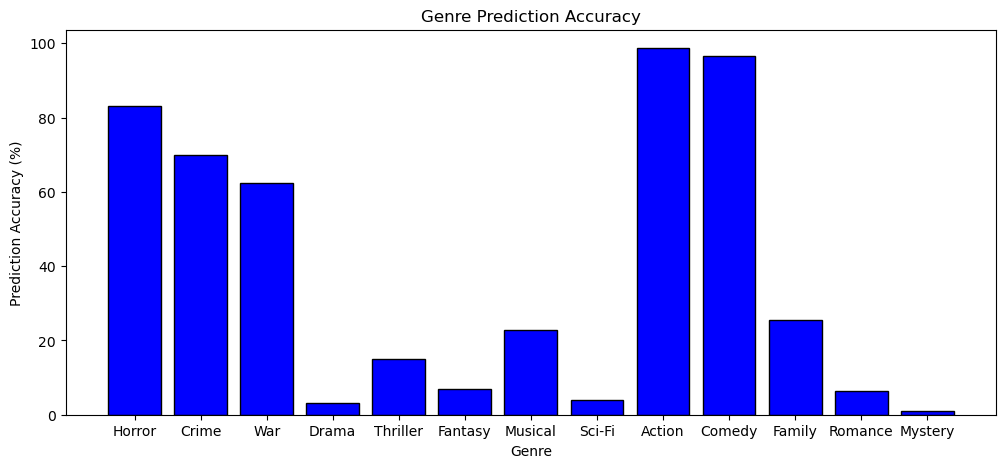

In [ ]:
# genre accuracys bar plot
genre_actual = {genre: 0 for genre in MANUAL_GENRE_VECTORS.keys()}
genre_matches = {genre: 0 for genre in MANUAL_GENRE_VECTORS.keys()}

for movie in data:
    script_text = movie["script"]
    comments = movie["comments"]
    comments_text = " ".join(comments) if comments else ""
    full_text = script_text + " " + comments_text
    tokens = clean_text(full_text)

    vocabulary = []
    for words in MANUAL_GENRE_VECTORS.values():
        for word in words:
            if word not in vocabulary:
                vocabulary.append(word)
    script_vector = np.array([tokens.count(word) for word in vocabulary], dtype=float)

    scores = {}
    for genre, words in MANUAL_GENRE_VECTORS.items():
        genre_vector = np.array([1 if word in words else 0 for word in vocabulary], dtype=float)
        scores[genre] = cosine_similarity(script_vector, genre_vector)

    predicted_genres = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]
    predicted = [genre[0] for genre in predicted_genres]

    # count actual and matches for each genre
    if movie["genres"]:
        actual = movie["genres"]
        for genre in MANUAL_GENRE_VECTORS.keys():
            if genre in actual:
                genre_actual[genre] += 1
                if genre in predicted:
                    genre_matches[genre] += 1

genre_accuracy = {}
for genre in MANUAL_GENRE_VECTORS.keys():
    if genre_actual[genre] > 0:
        genre_accuracy[genre] = genre_matches[genre] / genre_actual[genre] * 100
    else:
        genre_accuracy[genre] = 0 

genres = genre_accuracy.keys()
accuracy_values = [genre_accuracy[genre] for genre in genres]
print(genre_accuracy)

# plot each genres prediction accuracy
plt.figure(figsize=(12,5))
plt.bar(genres, accuracy_values, color='blue', edgecolor='black')
plt.xlabel("Genre")
plt.ylabel("Prediction Accuracy (%)")
plt.title("Genre Prediction Accuracy")
plt.show()

In [ ]:
k_values = range(1, 21)
train_accuracies_knn = []
test_accuracies_knn = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_accuracies_knn.append(knn.score(X_train, y_train))
    test_accuracies_knn.append(knn.score(X_test, y_test))

optimal_k = k_values[np.argmax(test_accuracies_knn)]

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies_knn, marker="o", label="Training Accuracy")
plt.plot(k_values, test_accuracies_knn, marker="o", label="Testing Accuracy")
plt.axvline(optimal_k, linestyle="--", label=f"Optimal k = {optimal_k}")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN Training and Testing Accuracy by k")
plt.xticks(list(k_values))
plt.legend()
plt.grid(True)
plt.show()

print("Optimal k:", optimal_k)
print("Best test accuracy:", max(test_accuracies_knn))